### Architecture
In this experiment, the data is first splitted into training and testing with 70%, 30% respectively. Earlyfusion models were trained using 5 folds and then single best fold model as well as the ensemble prediction of all 5 models are picked on test data. the single best model was for the exp5 and the ensemble of 5 folds prediction is compared with that exp5 single best model

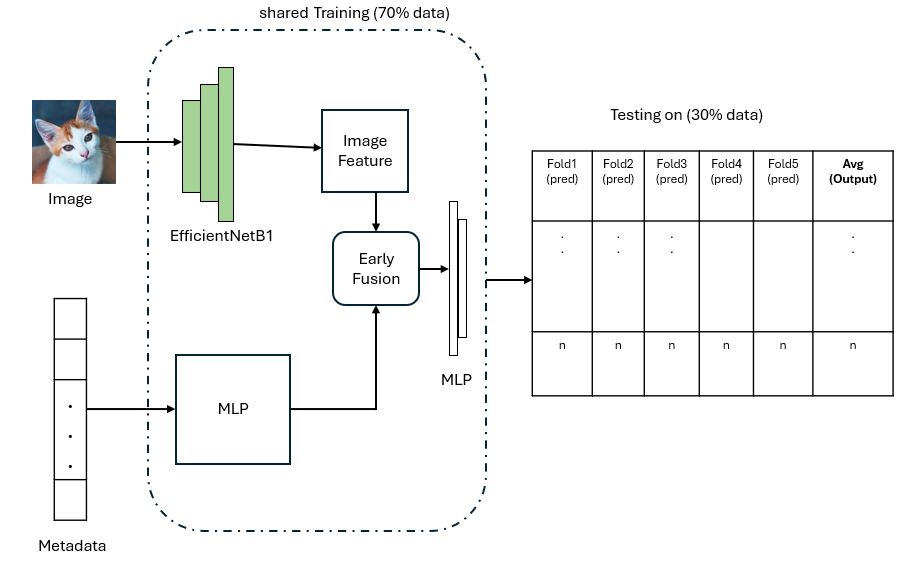


### Analysis
The 5-fold ensemble (Exp10) performs better overall by reducing the RMSE in the more records target range, which contains most of the samples, leading to a lower total error. However, the lower number of records region has still highest errors. this is because all the fold models are unable to give less error in the higher target region which means the overall populated region prediction is improved but the extreme target are misclassified

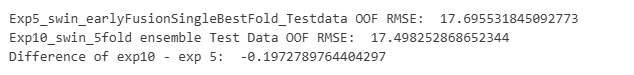
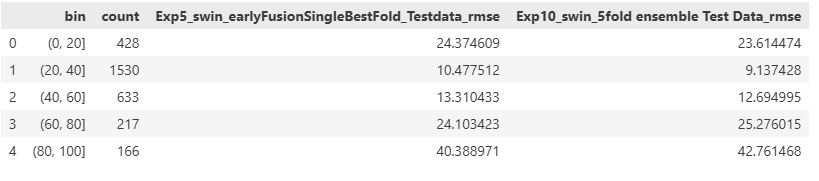

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath(".."))

In [3]:

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

gc.enable()

import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import KFold, StratifiedShuffleSplit
from sklearn.metrics import root_mean_squared_error

from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config
from src.data import build_transforms, ImageTabDataset
from src.models import FeatureConcatFusionNet

main_folder = ".."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs", "exp10")

df = pd.read_csv(data_csv)
# since all the configurations are similar to exp5, we will use exp5 config as base, the only difference , here the data is splitted for testing and the final into training and testing
# and the final RMSE is calculated by averaging the test data prediction of all 5 models. 
cfg = EXP_CONFIGS["exp5"]
cfg["name"] = "exp10_SWIN_EarlyFusion_CV_Ensemble"
TARGET = "Pawpularity"

# ---------- STRATIFIED 70/30 SPLIT ----------
df["bins"] = pd.qcut(df[TARGET], q=10, labels=False, duplicates='drop')


splitter = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=cfg["seed"]
)

for train_idx, test_idx in splitter.split(df, df["bins"]):
    train_df = df.iloc[train_idx].reset_index(drop=True)
    test_df  = df.iloc[test_idx].reset_index(drop=True)

train_df = train_df.drop(columns=["bins"])
test_df  = test_df.drop(columns=["bins"])

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

# tabular columns remain same
tab_cols = [c for c in df.columns if c not in ["Id", TARGET, "bins"]]

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train size: (6938, 14)
Test size: (2974, 14)


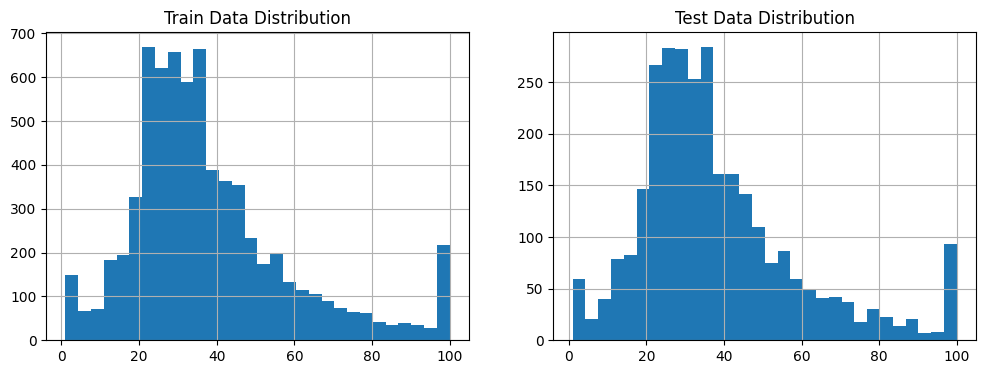

In [31]:
#  to visualize the distribution if the train and test have similar spread of target values to cover all ranges.
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
train_df[TARGET].hist(bins=30)
plt.title("Train Data Distribution")

plt.subplot(1,2,2)
test_df[TARGET].hist(bins=30)
plt.title("Test Data Distribution")
plt.show()


In [ ]:

#  5-Fold CV on 70% train data
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])

oof_pred = np.zeros(len(train_df))
oof_true = train_df[TARGET].values
fold_index = np.full(len(train_df), -1, dtype=int)
fold_rmse = []

start_all = time.time()

for fold, (tr_idx, val_idx) in enumerate(kf.split(train_df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")

    tr_df = train_df.iloc[tr_idx].reset_index(drop=True)
    val_df   = train_df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
        fold=fold,
        train_df=tr_df,
        val_df=val_df,
        img_folder=img_folder,
        cfg=cfg,
        out_dir=out_dir,
        device=device,
        mode="fusion",
        tab_cols=tab_cols,
        workers=16,
        pin_memory=True,
        persistent_workers=True,
    )

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")

# ---------- OOF stats ----------
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)

print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": train_df["Id"],
    "fold": fold_index,
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)

oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)

with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")




=== exp10_SWIN_EarlyFusion_CV_Ensemble: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[BCE]: Loss=0.6495 | ValRMSE: 18.3069
Epoch 2/10 | Fold 1 | Train[BCE]: Loss=0.6364 | ValRMSE: 19.1294
Epoch 3/10 | Fold 1 | Train[BCE]: Loss=0.6271 | ValRMSE: 19.3605
Epoch 4/10 | Fold 1 | Train[BCE]: Loss=0.6182 | ValRMSE: 18.4709
Epoch 5/10 | Fold 1 | Train[BCE]: Loss=0.6068 | ValRMSE: 19.3906
Epoch 6/10 | Fold 1 | Train[BCE]: Loss=0.5997 | ValRMSE: 19.0987
Early stopping at epoch 6
Fold 1 best RMSE: 18.3069

=== exp10_SWIN_EarlyFusion_CV_Ensemble: Fold 2 ===
Epoch 1/10 | Fold 2 | Train[BCE]: Loss=0.6499 | ValRMSE: 17.8328
Epoch 2/10 | Fold 2 | Train[BCE]: Loss=0.6391 | ValRMSE: 17.8654
Epoch 3/10 | Fold 2 | Train[BCE]: Loss=0.6291 | ValRMSE: 17.8818
Epoch 4/10 | Fold 2 | Train[BCE]: Loss=0.6181 | ValRMSE: 18.1447
Epoch 5/10 | Fold 2 | Train[BCE]: Loss=0.6074 | ValRMSE: 18.3556
Epoch 6/10 | Fold 2 | Train[BCE]: Loss=0.5986 | ValRMSE: 18.4401
Early stopping at epoch 6
Fold 2 best RMSE: 17.8328

=== exp10_S

 > The above shown rmse is on validation data, and now we will calculate the fold wise rmse on test data. for that each fold model will predict the output and in the end , all the predictions from 5 models are averaged and the rmse is calculated using that average and true value. 

In [4]:

from src.inference import infer_test_ensemble
test_pred_mean, all_fold_preds, fold_rmses, rmse_ens = infer_test_ensemble(
    test_df=test_df,
    img_folder=img_folder,
    cfg=cfg,
    out_dir=out_dir,
    device=device,
    tab_cols=tab_cols,
    workers=16,
)

y_true = test_df[TARGET].values



Fold 1 Model RMSE on test set: 17.8951
Fold 2 Model RMSE on test set: 17.9295
Fold 3 Model RMSE on test set: 17.6955
Fold 4 Model RMSE on test set: 17.9139
Fold 5 Model RMSE on test set: 18.2045

Ensemble mean RMSE on test set: 17.4983


In [9]:
print("avg of rmse: ",np.mean(fold_rmses))
print("std of rmse", np.std(fold_rmses))

avg of rmse:  17.927741241455077
std of rmse 0.16235720377780646


In [14]:
exp5_rmse = fold_rmses[np.argmin(fold_rmses)]
print("Exp5_swin_earlyFusionSingleBestFold_Testdata OOF RMSE: ",exp5_rmse )
print("Exp10_swin_5fold ensemble Test Data OOF RMSE: ", rmse_ens)
print("Difference of exp10 - exp 5: ",rmse_ens-exp5_rmse )

Exp5_swin_earlyFusionSingleBestFold_Testdata OOF RMSE:  17.695531845092773
Exp10_swin_5fold ensemble Test Data OOF RMSE:  17.498252868652344
Difference of exp10 - exp 5:  -0.1972789764404297


In [ ]:
#  fold-wise / ensemble detail df
test_cv_df = pd.DataFrame({
    "Id": test_df["Id"].values,
    "ytrue": y_true,
})

#  fold-wise prediction columns
for i in range(cfg["n_splits"]):
    test_cv_df[f"fold{i+1}_pred"] = all_fold_preds[i]

# ensemble average
test_cv_df["avg"] = test_pred_mean

# absolute error of ensemble
test_cv_df["abs_err"] = (test_cv_df["ytrue"] - test_cv_df["avg"]).abs()

#  -1 as test data has no folds
test_cv_df["fold"] = -1

# reorder columns 
cols = ["Id", "fold", "ytrue"] + \
       [f"fold{i+1}_pred" for i in range(cfg["n_splits"])] + \
       ["avg", "abs_err"]
test_cv_df = test_cv_df[cols]

# save
test_cv_df.to_csv(os.path.join(out_dir, "test_cv_df.csv"), index=False)
top_errors = test_cv_df.sort_values(by="abs_err", ascending=False)

# Save top 50
top_errors.head(50).to_csv(
    os.path.join(out_dir, "CV_testdata_top_50_errors.csv"),
    index=False
)

In [6]:
test_cv_df.head()

,Id,fold,ytrue,fold1_pred,fold2_pred,fold3_pred,fold4_pred,fold5_pred,avg,abs_err
0,eaa7d909c1f3fac946be7acc768ecc3e,-1,99,55.151535,59.174747,68.099739,58.098106,55.161415,59.137108,39.862892
1,b8ceb2877086b0db683ed28d0dbf6b3a,-1,22,31.511005,24.815277,29.273453,22.484533,24.413065,26.499466,4.499466
2,232193022ce0e9a7433f76e543992000,-1,40,31.039825,33.525578,27.875154,29.641380,27.188391,29.854065,10.145935
3,1d3dd097162e7022fca80feb7882c260,-1,24,23.642958,26.518717,22.174925,20.199024,25.934210,23.693968,0.306032
4,a4cfe1ab4ef8e23451c250660e09de9a,-1,18,27.053818,29.786366,22.102282,21.812929,21.930126,24.537104,6.537104


In [8]:
#  Inspect worst error rows

errors_path = os.path.join(out_dir, "CV_testdata_top_50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()

,Id,fold,ytrue,fold1_pred,fold2_pred,fold3_pred,fold4_pred,fold5_pred,avg,abs_err
0,941e532a21f7edb21766e88a15e588cb,-1,100,30.358910,24.657959,30.250532,25.223423,26.622025,27.422571,72.577429
1,4435d6f98ad72782ca0cf61f946b016d,-1,100,30.365350,30.466465,28.426193,25.391546,27.428010,28.415516,71.584484
2,deb8d1618d0cdc2a78c8198b882ebb2b,-1,100,29.255665,30.626133,32.825237,29.702377,33.979485,31.277777,68.722223
3,1e59bc4bf0f630df8f17fb908b7c13c2,-1,100,41.757195,35.200844,35.220660,29.353110,24.131240,33.132607,66.867393
4,bc6a496f4aa0f5dd352d6bd55732bcdc,-1,100,44.163624,27.721280,35.909210,29.236057,30.908897,33.587810,66.412189


Exp5_swin_earlyFusionSingleBestFold_Testdata OOF RMSE: 17.6955
Exp10_swin_5fold ensemble Test Data OOF RMSE: 17.4983


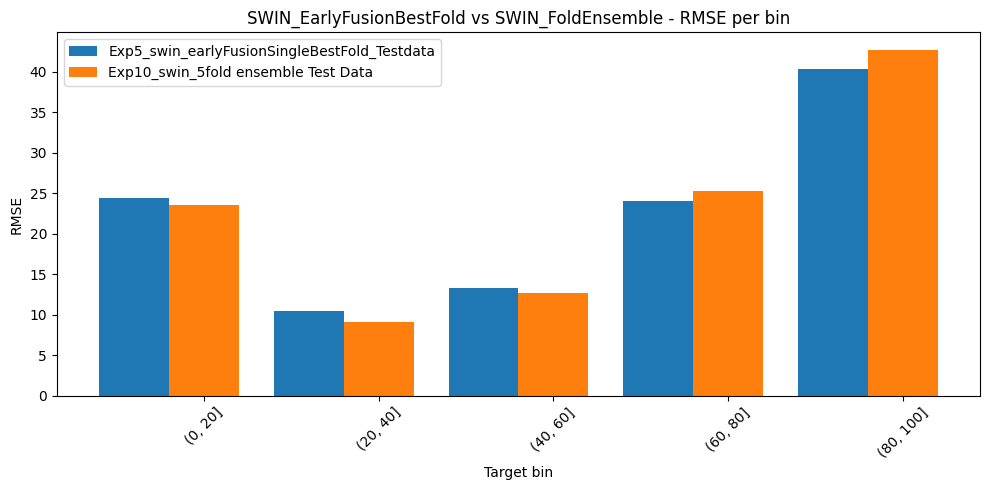

In [32]:
bins = [0, 20, 40, 60, 80, 100]
from src.plot import compare_oof_by_bins_multi

summary, overall = compare_oof_by_bins_multi(
    test_cv_df,
    bins=bins,
    y_col="ytrue",
    pred_cols={
        "Exp5_swin_earlyFusionSingleBestFold_Testdata": "fold3_pred",
        "Exp10_swin_5fold ensemble Test Data": "avg",
    },
    title_prefix="SWIN_EarlyFusionBestFold vs SWIN_FoldEnsemble"
)

In [ ]:
overall

In [25]:
summary.head()

,bin,count,Exp5_swin_earlyFusionSingleBestFold_Testdata_rmse,Exp10_swin_5fold ensemble Test Data_rmse
0,"(0, 20]",428,24.374609,23.614474
1,"(20, 40]",1530,10.477512,9.137428
2,"(40, 60]",633,13.310433,12.694995
3,"(60, 80]",217,24.103423,25.276015
4,"(80, 100]",166,40.388971,42.761468


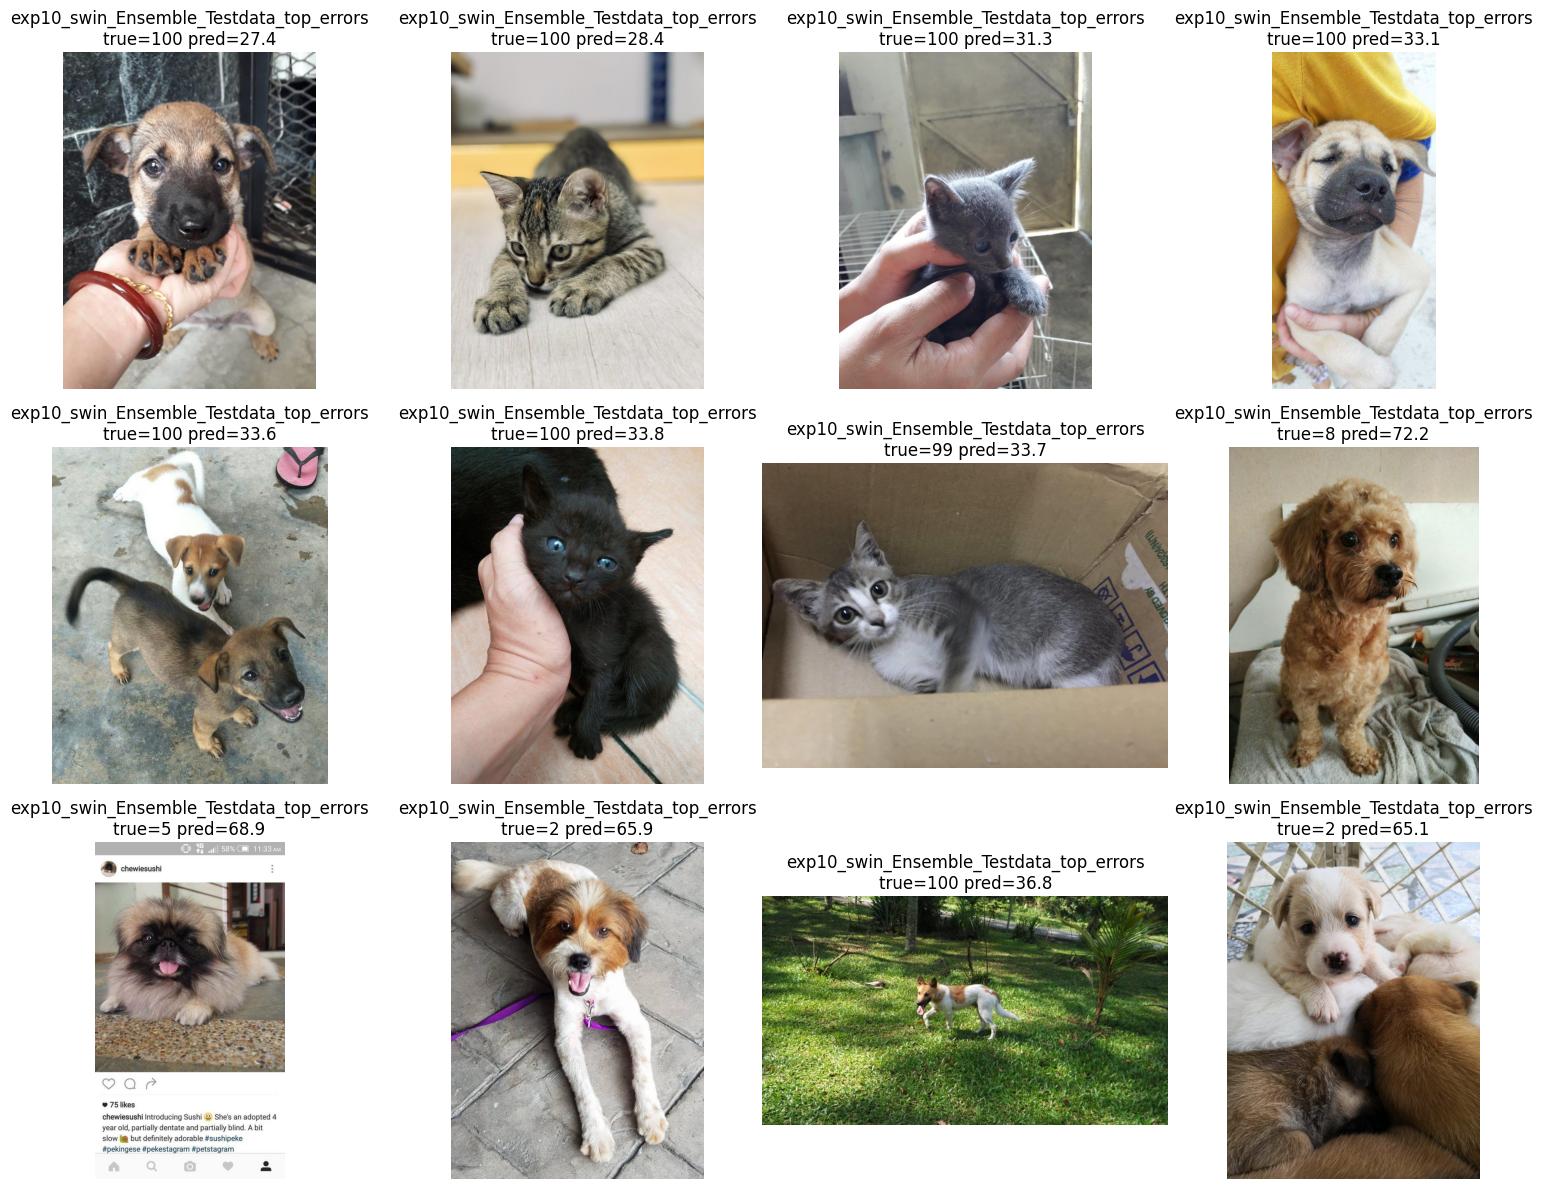

In [29]:
# Images of worst errors
from src.plot import show_images_grid
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix="exp10_swin_Ensemble_Testdata_top_errors",pred_col="avg")

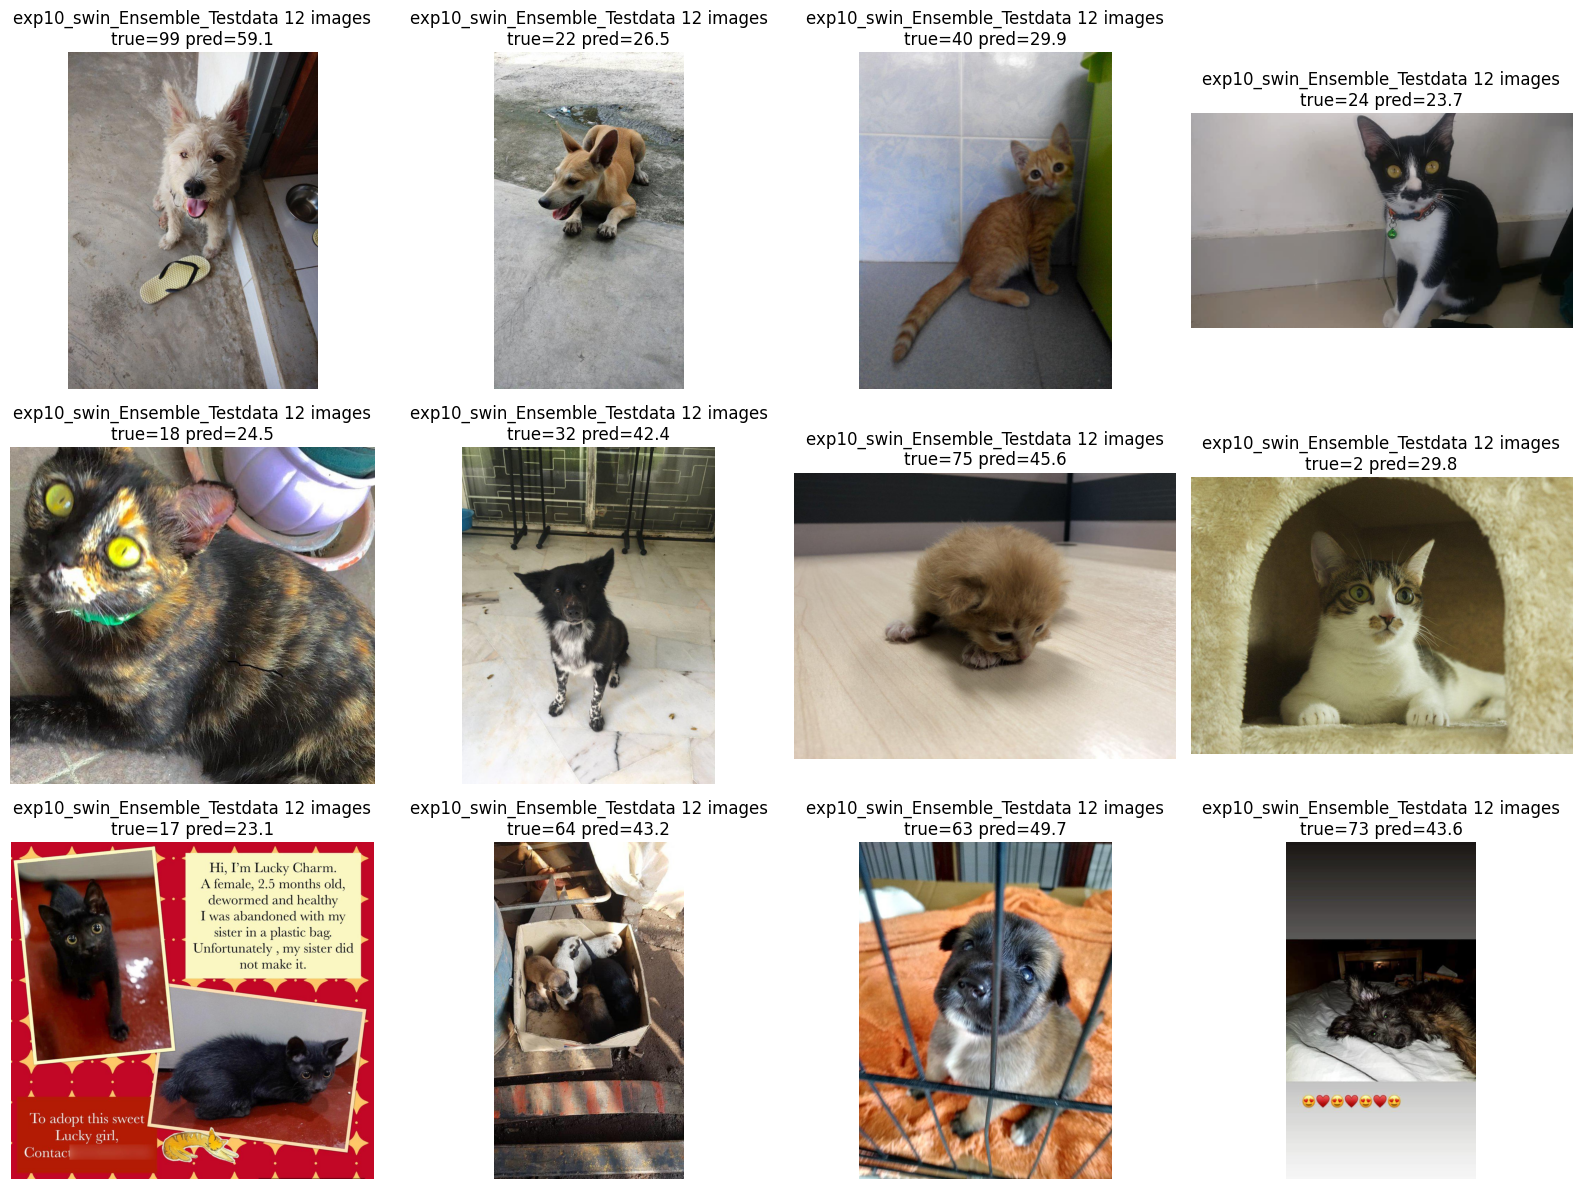

In [30]:

show_images_grid(test_cv_df, img_folder, n=12, pred_col="avg", title_prefix="exp10_swin_Ensemble_Testdata 12 images")